## Tugas 5

Kerjakan tiga soal di bawah dalam 1 Jupyter Notebook. Kumpulkan pada GitHub repo masing-masing paling lambat **Sabtu, 18 April 2026 pukul 23:59 WIB**.

Untuk **SOAL 1 dan 2**, diketahui data eksperimen pengukuran percepatan gravitasi dengan mengukur periode osilasi bandul terhadap panjang bandul sebagai berikut:

| Indeks data i | Panjang L (m) | Periode terukur T (s) |
|:-----:|:-----------------:|:-------------------------:|
|  1    |       0.20        |        0.9324            |
|  2    |       0.65        |        1.6253            |
|  3    |       1.10        |        2.1236            |
|  4    |       1.55        |        2.5424            |
|  5    |       2.00        |        2.8744            |

Dalam pendekatan osilasi sudut kecil, kita memiliki hubungan antara periode osilasi dan panjang bandul sebagai berikut:
$$
T = 2\pi \sqrt{\frac{L}{g}}
$$
atau
$$
T^2 = \frac{4\pi^2}{g} L
$$

Penentuan nilai percepatan gravitasi $g$ adalah permasalahan yang ingin dipecahkan dalam tugas soal 1 dan 2.

**SOAL 1**

Gunakan metode regresi kuadrat terkecil untuk mendapatkan nilai $g$. Uraikan langkah-langkah algoritma beserta kode Python implementasinya.

Slope (4*pi^2/g) = 4.135068637777779
Intercept = 0.0007484844444438706
Nilai g = 9.547221839000347 m/s^2


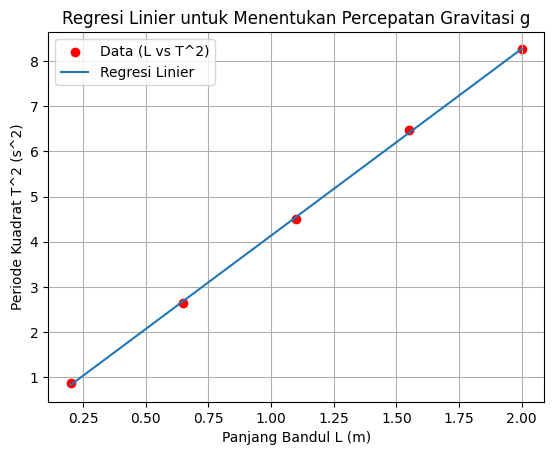

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data dari soal
L = np.array([0.20, 0.65, 1.10, 1.55, 2.00])
T = np.array([0.9324, 1.6253, 2.1236, 2.5424, 2.8744])

# Transformasi T^2 = (4*pi^2)/g * L
T2 = T**2

# Regresi linier y = m*x + c, dimana y=T^2, x=L, m=(4*pi^2)/g
coef = np.polyfit(L, T2, 1) # orde 1
slope = coef[0]
intercept = coef[1]

# Hitung g dari slope: slope = (4*pi^2)/g  => g = (4*pi^2)/slope
g = (4 * np.pi**2) / slope

print("Slope (4*pi^2/g) =", slope)
print("Intercept =", intercept)
print("Nilai g =", g, "m/s^2")

# Plot hasil regresi
plt.scatter(L, T2, color='red', label='Data (L vs T^2)')
plt.plot(L, np.polyval(coef, L), label='Regresi Linier')
plt.xlabel('Panjang Bandul L (m)')
plt.ylabel('Periode Kuadrat T^2 (s^2)')
plt.legend()
plt.title('Regresi Linier untuk Menentukan Percepatan Gravitasi g')
plt.grid(True)
plt.show()

**SOAL 2**

Gunakan metode interpolasi polinomial derajat 4 untuk menentukan nilai $g$ dengan data yang sama seperti SOAL 1. Uraikan langkah-langkah algoritma beserta kode Python implementasinya. Diskusikan perbedaan hasil yang mungkin muncul antara metode interpolasi dengan regresi.

Nilai g (Interpolasi) = 9.616501459771222 m/s^2


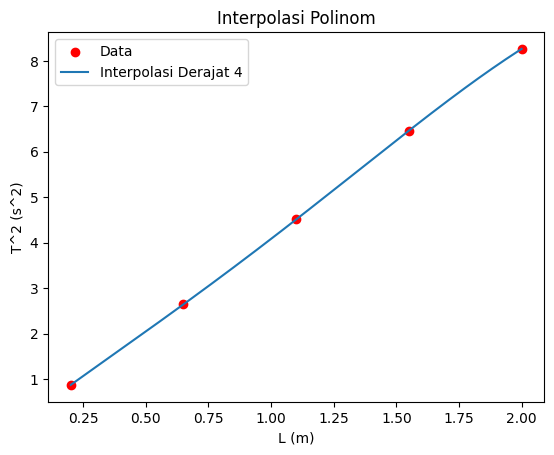

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data
L = np.array([0.20, 0.65, 1.10, 1.55, 2.00])
T = np.array([0.9324, 1.6253, 2.1236, 2.5424, 2.8744])

T2 = T**2

# Interpolasi polinom derajat 4
coef = np.polyfit(L, T2, 4)

# Fungsi polinom
def P(x):
    return np.polyval(coef, x)

# Data halus
L_new = np.linspace(min(L), max(L), 200)
T2_new = P(L_new)

# Turunan (slope lokal)
dT2_dL = np.gradient(T2_new, L_new)
slope = np.mean(dT2_dL)

# Hitung g
g = (4 * np.pi**2) / slope

print("Nilai g (Interpolasi) =", g, "m/s^2")

# Plot
plt.scatter(L, T2, color='red', label='Data')
plt.plot(L_new, T2_new, label='Interpolasi Derajat 4')
plt.xlabel('L (m)')
plt.ylabel('T^2 (s^2)')
plt.legend()
plt.title('Interpolasi Polinom')
plt.show()

**SOAL 3**

Carilah/buatlah sembarang data dua dimensi lainnya yang mengandung pasangan $(x_i, y_i)$ sebanyak 10 titik data, dengan syarat bahwa $x_i$ dan $y_i$ adalah suatu besaran fisika dengan makna tertentu (seperti contoh panjang dan periode osilasi pada kasus penentuan konstanta gravitasi di atas). Lakukan metode regresi dan interpolasi untuk menghasilkan pencocokan kurva pada 10 titik data tersebut. Jika ada besaran/konstanta fisis (contoh seperti percepatan gravitasi) yang ditemukan berdasarkan regresi/interpolasi tersebut, analisislah hasilnya dengan membandingkan pada referensi yang tersedia di literatur/internet.

Konstanta pegas (k) = 99.75757575757572
Intercept = 0.11333333333333474


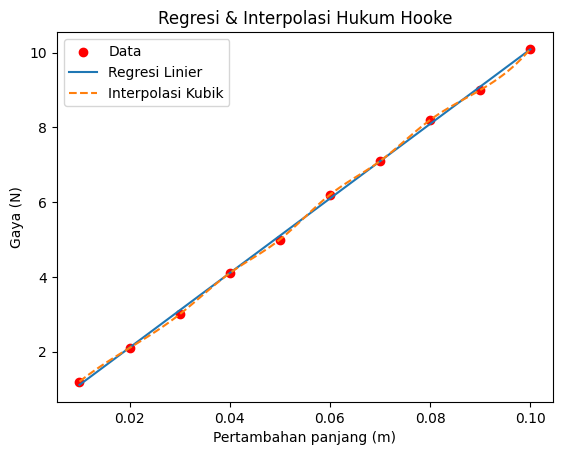

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Data
x = np.array([0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.10])
y = np.array([1.2,2.1,3.0,4.1,5.0,6.2,7.1,8.2,9.0,10.1])

# =====================
# REGRESI LINIER
# =====================
coef = np.polyfit(x, y, 1)   # orde 1
k = coef[0]
b = coef[1]

print("Konstanta pegas (k) =", k)
print("Intercept =", b)

y_reg = np.polyval(coef, x)

# =====================
# INTERPOLASI
# =====================
f_interp = interp1d(x, y, kind='cubic')

x_new = np.linspace(0.01, 0.10, 100)
y_interp = f_interp(x_new)

# =====================
# PLOT
# =====================
plt.scatter(x, y, color='red', label='Data')
plt.plot(x, y_reg, label='Regresi Linier')
plt.plot(x_new, y_interp, linestyle='--', label='Interpolasi Kubik')

plt.xlabel('Pertambahan panjang (m)')
plt.ylabel('Gaya (N)')
plt.legend()
plt.title('Regresi & Interpolasi Hukum Hooke')
plt.show()